# Bitcoin Market Sentiment vs. Hyperliquid Trader Behavior & Performance

**Objective:** Explore and analyze the relationship between Bitcoin market sentiment
(Fear & Greed Index) and trader behavior/performance using historical Hyperliquid trade data.

This notebook orchestrates the full pipeline implemented in `src/`:
1. Data cleaning & merging (`src/data_processing.py`)
2. Feature engineering (`src/feature_engineering.py`)
3. Full analysis - EDA, sentiment performance, behavior, direction, trader-level,
   segmentation, overtrading, risk, asset, time-based, statistical testing,
   correlation, outlier/robustness (`src/run_analysis.py`)
4. Hidden patterns + executive summary synthesis (`src/final_report.py`)

Run all cells top-to-bottom. Figures are saved to `outputs/figures/` and tables to
`outputs/tables/` as a side effect, and also displayed inline below.

In [37]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
pd.set_option("display.max_columns", 30)

## Phase 1-3: Data Inspection, Cleaning & Merging

In [38]:
from src.data_processing import load_and_clean_sentiment, load_and_clean_trades, merge_datasets

sentiment = load_and_clean_sentiment()
trades = load_and_clean_trades()
merged = merge_datasets(trades, sentiment)
merged.head()


CLEANING: Fear & Greed Sentiment Data
All classification values match expected 5-category scheme: ['Extreme Fear', 'Extreme Greed', 'Fear', 'Greed', 'Neutral']
Duplicate calendar dates: 0
Rows before cleaning: 2644 -> after cleaning: 2644
Date range: 2018-02-01 to 2025-05-02

CLEANING: Historical Trader Data (Hyperliquid)
Rows loaded: 211224
Raw 'timestamp' column has only 7 distinct values (precision-loss artifact) -> NOT used for time reconstruction.
Unparseable 'timestamp_ist' values: 0
Missing values after numeric coercion:
 Series([], dtype: int64)
Fully duplicated rows: 0
Orders with >1 fill (partial fills, expected/legit): 21176 of 50555 orders
Rows with size_usd <= 0: 43 (mostly 'Spot Dust Conversion' events; kept, but excluded from size-dependent ratio calcs to avoid divide-by-zero)
99th percentile of |closed_pnl|: 1215.21 (extreme values retained - legitimate large trades)
Rows before cleaning: 211224 -> after cleaning: 211224
Date range (trade_date): 2023-05-01 to 2025-05-0

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,datetime_ist,trade_date,trade_hour,day_of_week,sentiment_value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed


## Phase 4: Feature Engineering

In [39]:
from src.feature_engineering import add_trade_level_features, trader_level_aggregates, MIN_TRADES_THRESHOLD

df = add_trade_level_features(merged)
closing = df[df["is_closing_trade"]].copy()
closing_sent = closing[closing["sentiment"].notna()].copy()
print(f"Total fills: {len(df):,} | Closing fills: {len(closing):,} | Unique traders: {df['account'].nunique()}")
df.head()

Total fills: 211,224 | Closing fills: 104,408 | Unique traders: 32


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,datetime_ist,trade_date,trade_hour,day_of_week,sentiment_value,sentiment,is_closing_trade,is_profitable,is_loss,absolute_pnl,fee_to_size_ratio,pnl_to_size_ratio,size_bucket,is_buy
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed,False,False,False,0.0,0.000044,0.0,Very Large,True
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed,False,False,False,0.0,0.000044,0.0,Small,True
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed,False,False,False,0.0,0.000044,0.0,Large,True
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed,False,False,False,0.0,0.000044,0.0,Large,True
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,22,Monday,80.0,Extreme Greed,False,False,False,0.0,0.000044,0.0,Small,True


## Phases 5-17: Full Analysis

The full analysis (EDA, sentiment performance, behavior analysis, direction analysis,
trader-level aggregation, segmentation, overtrading, risk, asset, time-based,
statistical testing, correlation, and outlier/robustness checks) is implemented in
`src/run_analysis.py`. We execute it here as a script so all printed output, tables,
and figures are generated in one reproducible pass.

In [40]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, str(Path.cwd().parent / "src" / "run_analysis.py")],
    cwd=str(Path.cwd().parent), capture_output=True, text=True
)
print(result.stdout[-6000:])  # tail of console output
if result.returncode != 0:
    print(result.stderr)

 
@107        17166  2783912.92      0.82  2.749510e+07
HYPE        32011  1948484.60      0.88  7.089582e+07
SOL          5030  1639555.93      0.84  6.215848e+07
ETH          5228  1319978.84      0.77  5.886913e+07
BTC         11009   868044.73      0.83  3.210274e+08
MELANIA      2211   390351.07      0.89  3.571759e+06
ENA           332   217329.50      0.93  6.135842e+05
SUI           893   199268.83      0.94  3.985028e+06
ZRO           794   183777.78      0.57  8.883717e+05
DOGE          459   147543.16      0.88  1.163571e+06
Saved table: C:\Users\venka\projects\sentiment-aplha\outputs\tables\asset_performance.csv

Mean PnL by top asset x sentiment:
sentiment  Extreme Fear    Fear  Neutral   Greed  Extreme Greed
coin                                                           
@107            -153.60   -4.22   113.64  143.78         313.61
BTC                4.58  111.16    91.60   35.98         103.05
ETH              349.90  472.73    82.54  225.46         -58.93
FARTCOIN    

### Key tables produced

In [41]:
tables_dir = Path.cwd().parent / "outputs" / "tables"
perf_by_sentiment = pd.read_csv(tables_dir / "performance_by_sentiment.csv", index_col=0)
perf_by_sentiment

,total_pnl,mean_pnl,median_pnl,pnl_std,n_trades,n_profitable,n_losing,win_rate,total_fees,avg_trade_size,avg_win,avg_loss,risk_adjusted,profit_factor
sentiment,,,,,,,,,,,,,,
Extreme Fear,7.391102e+05,71.0273,6.3880,1628.4083,10406,7931,2475,0.7622,12230.2413,5467.5704,173.4248,-257.0996,0.0436,2.1615
Fear,3.357155e+06,112.6260,6.3505,1344.7784,29808,26019,3789,0.8729,46999.2158,8041.1404,151.8409,-156.6624,0.0838,6.6556
Neutral,1.292921e+06,71.2000,4.5835,743.2129,18159,14961,3198,0.8239,22262.6890,5556.4448,112.4394,-121.7278,0.0958,4.3213
Greed,2.150129e+06,85.4039,4.9276,1576.3948,25176,19358,5818,0.7689,29677.6870,5438.6718,165.7617,-181.9673,0.0542,3.0309
Extreme Greed,2.715171e+06,130.2053,8.5307,1058.1261,20853,18594,2259,0.8917,13665.8626,2779.5636,160.5933,-119.9203,0.1231,11.0228


In [42]:
behavior_by_sentiment = pd.read_csv(tables_dir / "behavior_by_sentiment.csv", index_col=0)
behavior_by_sentiment

,n_trades,avg_trade_size,median_trade_size,total_volume,avg_fee,n_active_traders,buy_pct,sell_pct,calendar_days,trades_per_trader_per_day
sentiment,,,,,,,,,,
Extreme Fear,21400,5349.7318,766.150,1.144843e+08,1.1163,32,0.5110,0.4890,14,47.7679
Fear,61837,7816.1099,735.960,4.833248e+08,1.4952,32,0.4895,0.5105,91,21.2352
Neutral,37686,4782.7327,547.655,1.802421e+08,1.0448,31,0.5033,0.4967,67,18.1444
Greed,50303,5736.8844,555.000,2.885825e+08,1.2544,31,0.4886,0.5114,193,8.4077
Extreme Greed,39992,3112.2516,500.050,1.244652e+08,0.6759,30,0.4486,0.5514,114,11.6936


In [43]:
trader_segment_comparison = pd.read_csv(tables_dir / "trader_segment_comparison.csv", index_col=0)
trader_segment_comparison

,n_traders,avg_total_trades,avg_trade_size,avg_win_rate,avg_buy_pct,avg_fees,avg_pnl_std,avg_risk_adjusted,avg_trades_per_day
segment,,,,,,,,,
Top 20%,7,14015.5714,10821.4419,0.8469,0.4638,18764.6155,2287.0101,0.1563,250.3958
Middle 60%,18,5187.2222,3572.3237,0.8886,0.4703,4004.1209,1049.4270,0.2318,64.4690
Bottom 20%,7,2820.7143,7457.4028,0.7544,0.4410,6061.6052,834.3116,0.0388,98.4704


In [44]:
risk_by_sentiment = pd.read_csv(tables_dir / "risk_by_sentiment.csv", index_col=0)
risk_by_sentiment

,avg_position_size,pnl_volatility,max_loss,avg_loss,avg_fee_burden,risk_adjusted_perf
sentiment,,,,,,
Extreme Fear,5467.5704,1628.4083,-31036.6919,-257.0996,1.1753,0.0436
Fear,8041.1404,1344.7784,-35681.7472,-156.6624,1.5767,0.0838
Neutral,5556.4448,743.2129,-24500.0000,-121.7278,1.2260,0.0958
Greed,5438.6718,1576.3948,-117990.1041,-181.9673,1.1788,0.0542
Extreme Greed,2779.5636,1058.1261,-10259.4680,-119.9203,0.6553,0.1231


In [45]:
asset_performance = pd.read_csv(tables_dir / "asset_performance.csv", index_col=0)
asset_performance.sort_values("total_pnl", ascending=False).head(10)

,n_trades,total_pnl,win_rate,total_volume
coin,,,,
@107,17166,2.783913e+06,0.8170,2.749510e+07
HYPE,32011,1.948485e+06,0.8816,7.089582e+07
SOL,5030,1.639556e+06,0.8388,6.215848e+07
ETH,5228,1.319979e+06,0.7682,5.886913e+07
BTC,11009,8.680447e+05,0.8306,3.210274e+08
MELANIA,2211,3.903511e+05,0.8892,3.571759e+06
ENA,332,2.173295e+05,0.9337,6.135842e+05
SUI,893,1.992688e+05,0.9395,3.985028e+06
ZRO,794,1.837778e+05,0.5730,8.883717e+05


### Key figures produced

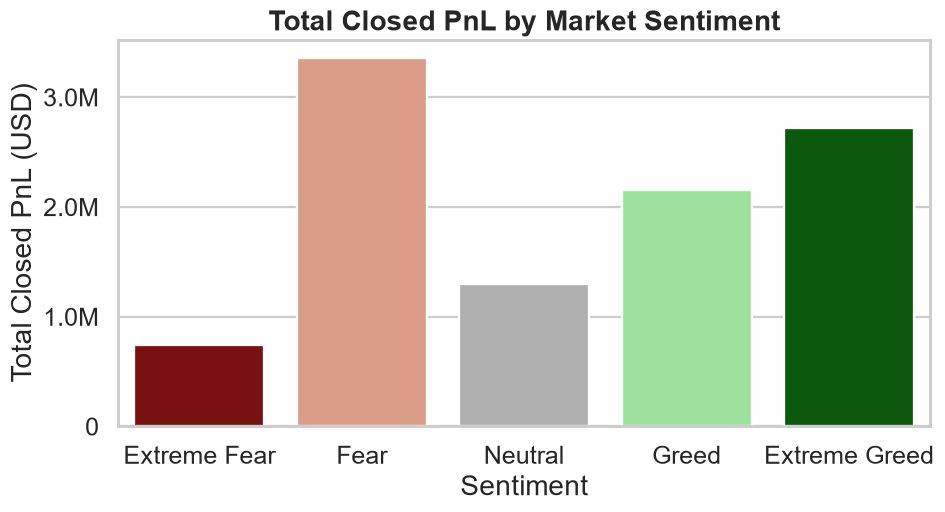

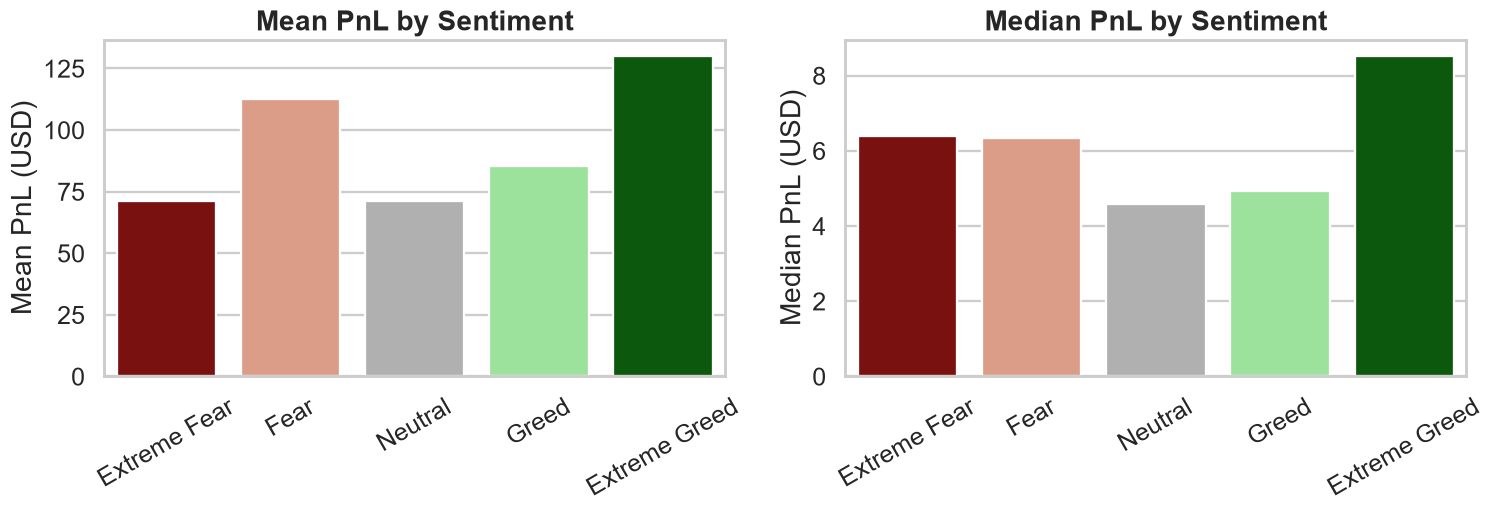

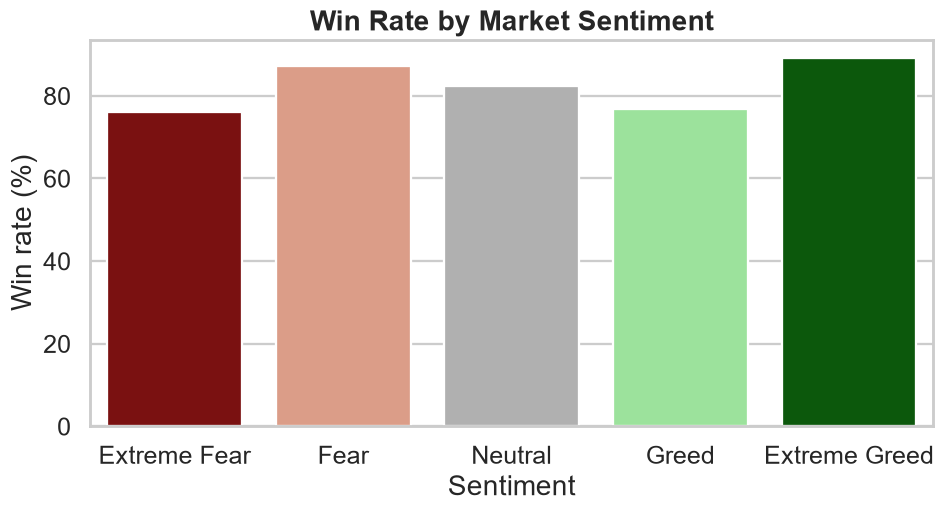

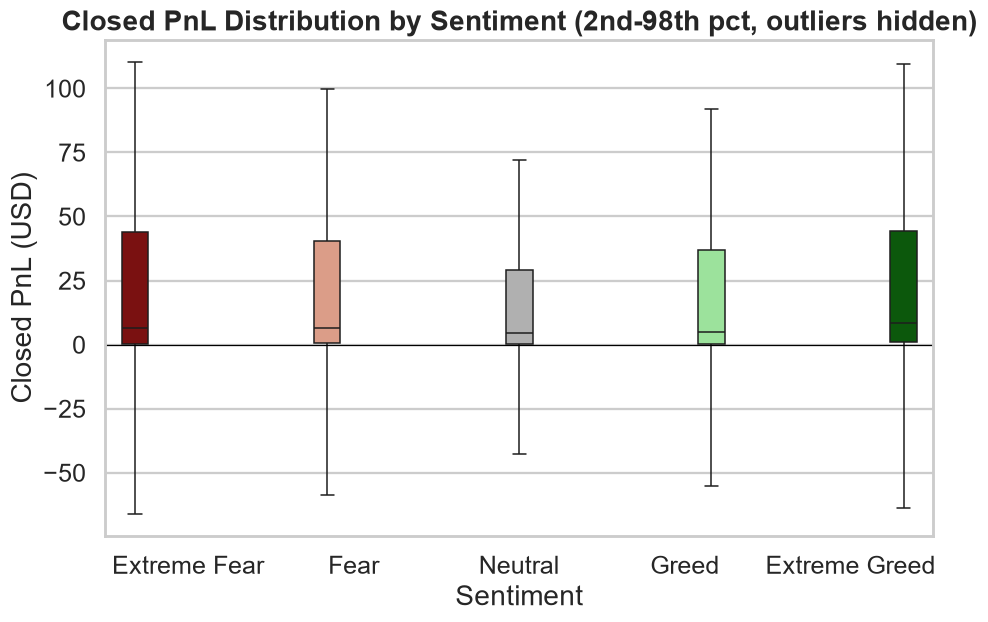

In [46]:
figs_dir = Path.cwd().parent / "outputs" / "figures"
for name in ["05_total_pnl_by_sentiment", "06_mean_vs_median_pnl_by_sentiment",
             "07_win_rate_by_sentiment", "08_pnl_boxplot_by_sentiment"]:
    display(Image(filename=str(figs_dir / f"{name}.png")))

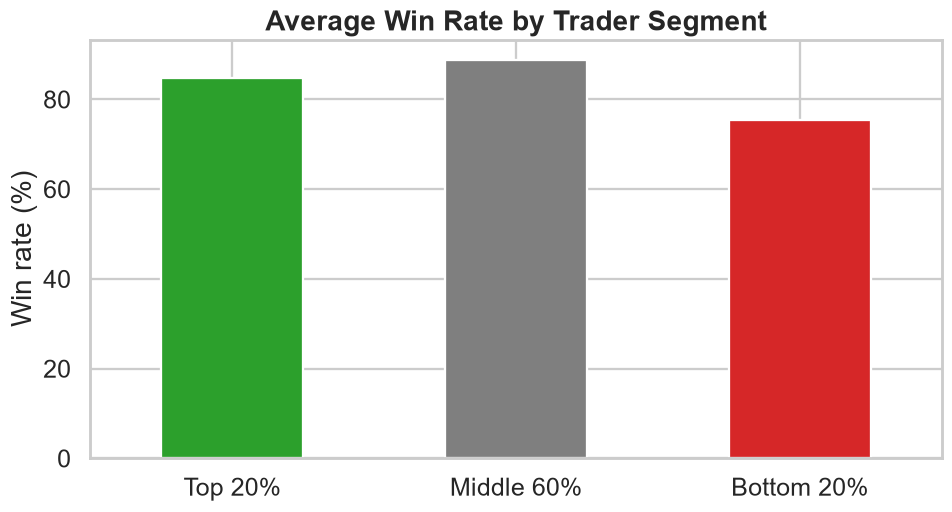

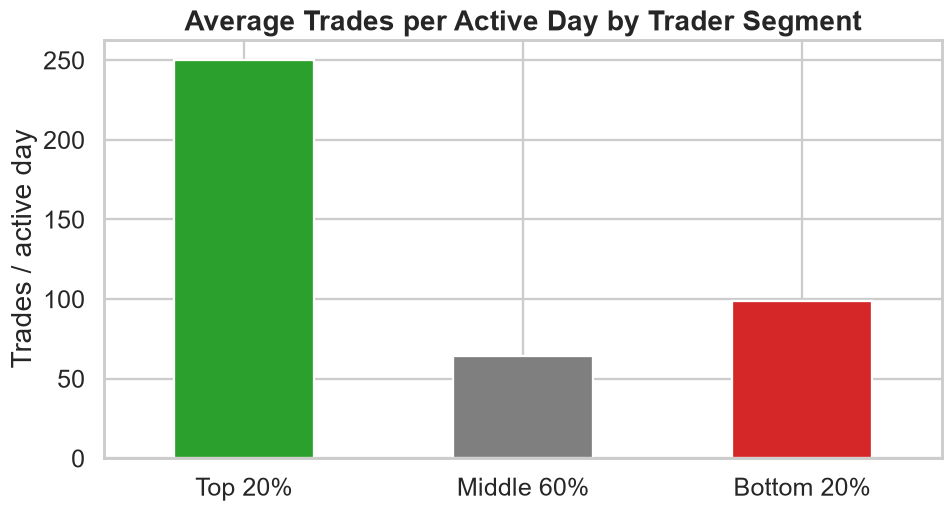

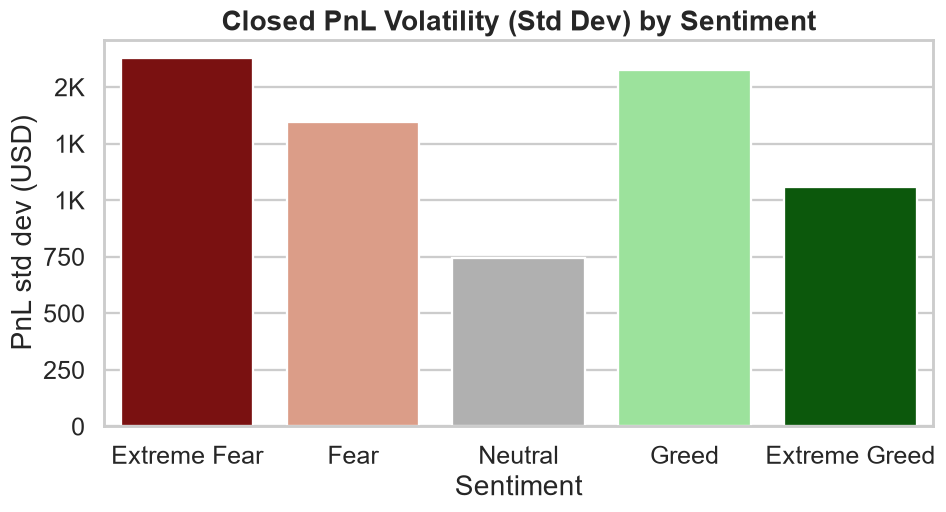

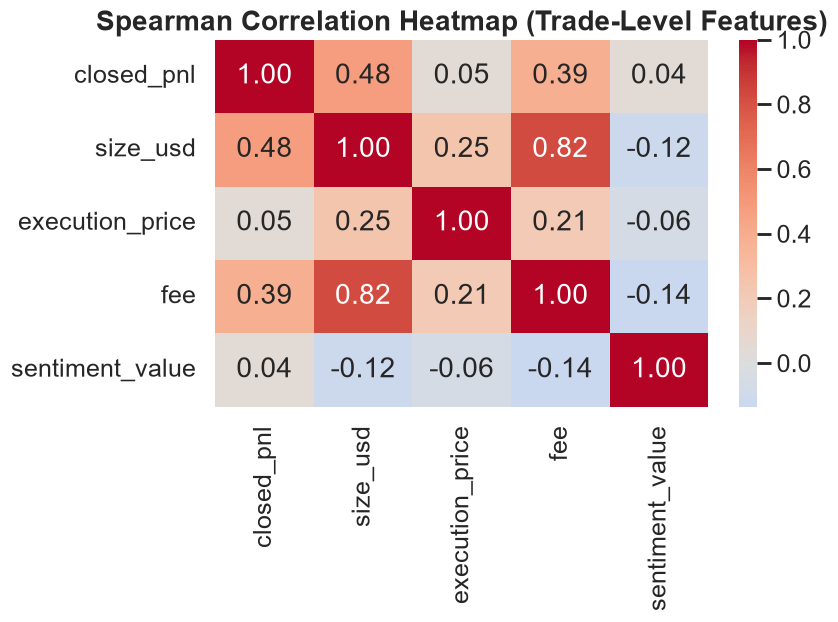

In [47]:
for name in ["12_win_rate_by_segment", "13_trade_frequency_by_segment",
             "15_pnl_volatility_by_sentiment", "18_correlation_heatmap"]:
    display(Image(filename=str(figs_dir / f"{name}.png")))

## Phases 19-21: Hidden Patterns, Strategy Insights & Executive Summary

In [48]:
result = subprocess.run(
    [sys.executable, str(Path.cwd().parent / "src" / "final_report.py")],
    cwd=str(Path.cwd().parent), capture_output=True, text=True
)
if result.returncode != 0:
    print(result.stderr)
summary_path = Path.cwd().parent / "outputs" / "tables" / "executive_summary.md"
display(Markdown(summary_path.read_text()))

Traceback (most recent call last):
  File "C:\Users\venka\projects\sentiment-aplha\src\final_report.py", line 197, in <module>
    out_path.write_text(report)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\pathlib.py", line 1079, in write_text
    return f.write(data)
           ^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2248' in position 2918: character maps to <undefined>

